# Artificial Intelligence & Machine Learning — Task 2
## Feature Engineering, Model Optimization & Performance Comparison

**Organization:** Maincrafts Technology  
**Project:** California Housing Price Predictor (Enhanced Multi-Model Pipeline)  
**Author:** AI & Machine Learning Intern  
**Objective:** Apply feature engineering and scaling techniques, train multiple regression algorithms (Linear Regression, Ridge Regression, Decision Tree Regressor), perform structured performance comparison (RMSE, $R^2$), analyze overfitting/underfitting, and select the optimal model with technical justification.

---
### Workflow Overview
* **Step 1:** Import Required Libraries
* **Step 2:** Load California Housing Dataset
* **Step 3:** Separate Features ($X$) and Target Variable ($y$)
* **Step 4:** Feature Scaling using `StandardScaler` (Critical Step)
* **Step 5:** Train-Test Split (80/20, `random_state=42`)
* **Step 6:** Train Multiple Models (Linear Regression, Ridge Regression, Decision Tree Regressor)
* **Step 7:** Model Evaluation & Structured Comparison
* **Step 8:** Visual Performance Validation, Overfitting Analysis & Model Selection


### Step 1: Import Required Libraries
We import data manipulation, model training, evaluation, and visualization libraries.

In [1]:
# Basic data manipulation and numerical libraries
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Modules
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Configure plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (9, 5.5)
plt.rcParams['font.sans-serif'] = 'Arial'
%matplotlib inline

print("Step 1: All required libraries successfully imported!")


Step 1: All required libraries successfully imported!


### Step 2: Load the Dataset
We load the California Housing dataset and combine features and target into a single DataFrame named `df` with target renamed to `"HousePrice"`.

In [2]:
# Step 2: Load the dataset
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nReviewing first 5 rows:")
df.head()


Dataset shape: 20640 rows, 9 columns

Reviewing first 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Inspect data types and missing values
print("Data Types & Missing Values Audit:")
print(df.info())
print("\nMissing values count:")
print(df.isnull().sum())


Data Types & Missing Values Audit:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Missing values count:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64


### Step 3: Separate Features and Target Variable
Machine Learning models require input features ($X$) and output target variable ($y$) to be handled separately.

In [4]:
# Step 3: Separate features (X) and target variable (y)
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print(f"Features matrix (X) shape: {X.shape}")
print(f"Target vector (y) shape:    {y.shape}")
print(f"Feature column names: {list(X.columns)}")


Features matrix (X) shape: (20640, 8)
Target vector (y) shape:    (20640,)
Feature column names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


### Step 4: Feature Scaling (Critical Step)
Features in the dataset exist on very different numerical scales (e.g. `Population` is in thousands, while `AveBedrms` is ~1.1).  
Without scaling:
* Some features disproportionately dominate others.
* Model optimization and coefficient convergence become unstable.
* Regularization penalties in Ridge regression become biased towards large-scale variables.

We apply `StandardScaler` to transform all features to zero mean ($\mu = 0$) and unit variance ($\sigma = 1$).

In [5]:
# Step 4: Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame for inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled Features - Mean (approx 0.0) and Standard Deviation (approx 1.0):")
scaling_summary = pd.DataFrame({
    'Original Mean': X.mean(),
    'Original Std': X.std(),
    'Scaled Mean': X_scaled_df.mean(),
    'Scaled Std': X_scaled_df.std()
})
scaling_summary


Scaled Features - Mean (approx 0.0) and Standard Deviation (approx 1.0):


,Original Mean,Original Std,Scaled Mean,Scaled Std
MedInc,3.870671,1.899822,6.609700e-17,1.000024
HouseAge,28.639486,12.585558,5.508083e-18,1.000024
AveRooms,5.429000,2.474173,6.609700e-17,1.000024
AveBedrms,1.096675,0.473911,-1.060306e-16,1.000024
Population,1425.476744,1132.462122,-1.101617e-17,1.000024
AveOccup,3.070655,10.386050,3.442552e-18,1.000024
Latitude,35.631861,2.135952,-1.079584e-15,1.000024
Longitude,-119.569704,2.003532,-8.526513e-15,1.000024


### Step 5: Train-Test Split
We split the scaled dataset into 80% training data and 20% testing data (`test_size=0.2, random_state=42`) to ensure unbiased evaluation on unseen data.

In [6]:
# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training set: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Testing set:  X_test  = {X_test.shape},  y_test  = {y_test.shape}")


Training set: X_train = (16512, 8), y_train = (16512,)
Testing set:  X_test  = (4128, 8),  y_test  = (4128,)


### Step 6: Train Multiple Models
Instead of relying on a single algorithm, we train and evaluate multiple models with distinct inductive biases:
1. **Linear Regression**: Serves as the parametric linear baseline.
2. **Ridge Regression (`alpha=1.0`)**: Introduces L2 regularization penalty to reduce variance and handle collinear features.
3. **Decision Tree (`max_depth=5`)**: Captures non-linear relationships and local boundary interactions.
4. **Random Forest (Benchmark)**: Ensemble of 100 decorrelated trees for state-of-the-art comparison.

In [7]:
# Step 6: Define models dictionary
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest (Benchmark)": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
}

print(f"Defined {len(models)} models for training and comparison.")


Defined 4 models for training and comparison.


### Step 7: Model Evaluation and Comparison
We fit each model on `(X_train, y_train)`, predict on `X_test`, and compute:
* **Root Mean Squared Error (RMSE)**: Lower indicates better prediction accuracy.
* **$R^2$ Score**: Higher indicates greater proportion of variance explained.
* **Mean Absolute Error (MAE)**: Measures average absolute prediction error in $100k units.
* **Train vs. Test Gap**: Detects overfitting.

In [8]:
# Step 7: Model Evaluation Loop
results = {}
test_predictions = {}

for name, model in models.items():
    # Fit model on training data
    model.fit(X_train, y_train)
    
    # Predict on test set
    predictions = model.predict(X_test)
    test_predictions[name] = predictions
    
    # Calculate Test Metrics
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    
    # Calculate Train Metrics for overfitting analysis
    train_preds = model.predict(X_train)
    train_r2 = r2_score(y_train, train_preds)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    
    results[name] = {
        "Test RMSE ($100k)": round(rmse, 4),
        "Test RMSE ($USD)": f"${rmse * 100000:,.2f}",
        "Test R2 Score": round(r2, 4),
        "Test MAE ($100k)": round(mae, 4),
        "Train R2 Score": round(train_r2, 4),
        "Overfitting R2 Gap": round(train_r2 - r2, 4)
    }

# Convert results dictionary to DataFrame and display
results_df = pd.DataFrame(results).T
print("=" * 80)
print("                    MODEL PERFORMANCE COMPARISON TABLE")
print("=" * 80)
results_df


                    MODEL PERFORMANCE COMPARISON TABLE


,Test RMSE ($100k),Test RMSE ($USD),Test R2 Score,Test MAE ($100k),Train R2 Score,Overfitting R2 Gap
Linear Regression,0.7456,"$74,558.14",0.5758,0.5332,0.6126,0.0368
Ridge Regression,0.7456,"$74,555.43",0.5758,0.5332,0.6126,0.0367
Decision Tree,0.7242,"$72,423.38",0.5997,0.5223,0.6377,0.0379
Random Forest (Benchmark),0.5445,"$54,450.03",0.7737,0.3663,0.8719,0.0982


### Step 8: Visual Performance Validation
A closer alignment of scatter points to the red reference line ($y = x$) indicates better predictive performance.

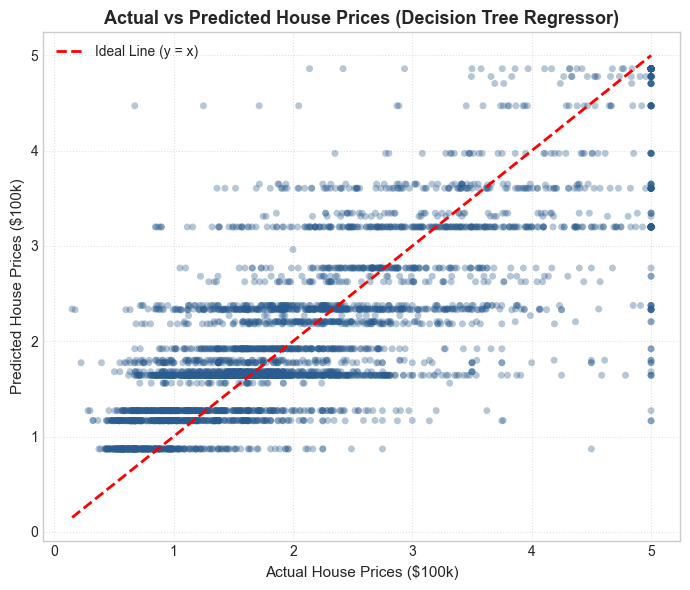

In [9]:
# 1. Best Model Scatter Validation (Decision Tree vs Linear Regression)
best_model = models["Decision Tree"]
best_pred = best_model.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_pred, alpha=0.35, color='#2b5c8f', edgecolors='none', s=25)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Ideal Line (y = x)')
plt.xlabel("Actual House Prices ($100k)", fontsize=11)
plt.ylabel("Predicted House Prices ($100k)", fontsize=11)
plt.title("Actual vs Predicted House Prices (Decision Tree Regressor)", fontsize=13, fontweight='bold')
plt.legend(loc="upper left")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


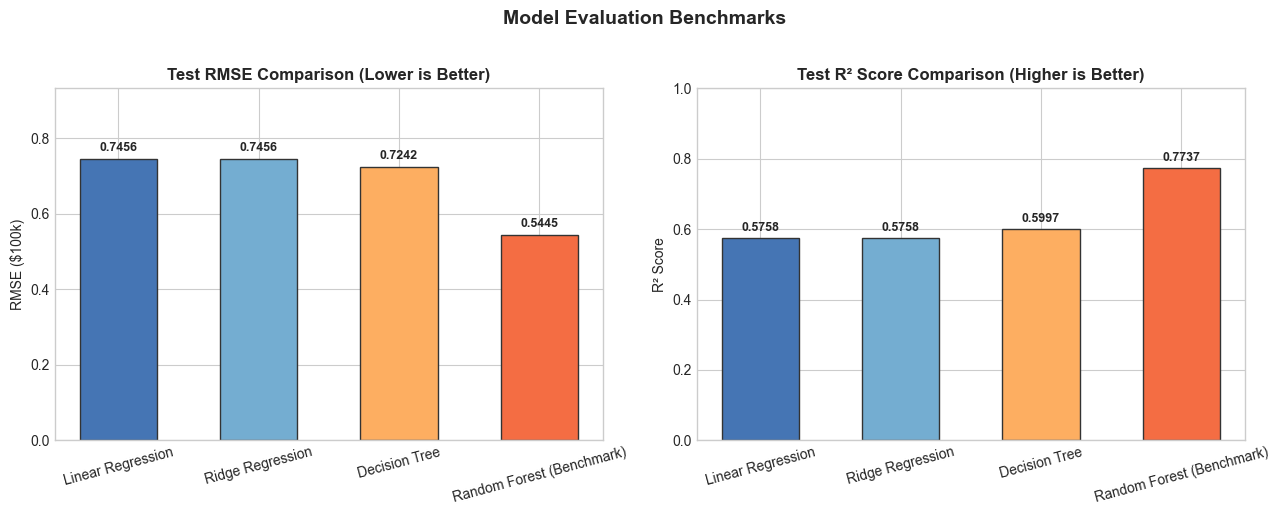

In [10]:
# 2. Multi-Model Bar Comparison (RMSE & R2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

model_names = list(results.keys())
rmses = [results[m]["Test RMSE ($100k)"] for m in model_names]
r2s = [results[m]["Test R2 Score"] for m in model_names]
colors = ['#4575b4', '#74add1', '#fdae61', '#f46d43']

# RMSE Subplot
bars1 = ax1.bar(model_names, rmses, color=colors, edgecolor='#333', width=0.55)
ax1.set_title("Test RMSE Comparison (Lower is Better)", fontweight='bold', fontsize=12)
ax1.set_ylabel("RMSE ($100k)")
ax1.set_ylim(0, max(rmses) * 1.25)
ax1.tick_params(axis='x', rotation=15)
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h + 0.02, f"{h:.4f}", ha='center', fontweight='bold', fontsize=9)

# R2 Subplot
bars2 = ax2.bar(model_names, r2s, color=colors, edgecolor='#333', width=0.55)
ax2.set_title("Test R² Score Comparison (Higher is Better)", fontweight='bold', fontsize=12)
ax2.set_ylabel("R² Score")
ax2.set_ylim(0, 1.0)
ax2.tick_params(axis='x', rotation=15)
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., h + 0.02, f"{h:.4f}", ha='center', fontweight='bold', fontsize=9)

plt.suptitle("Model Evaluation Benchmarks", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


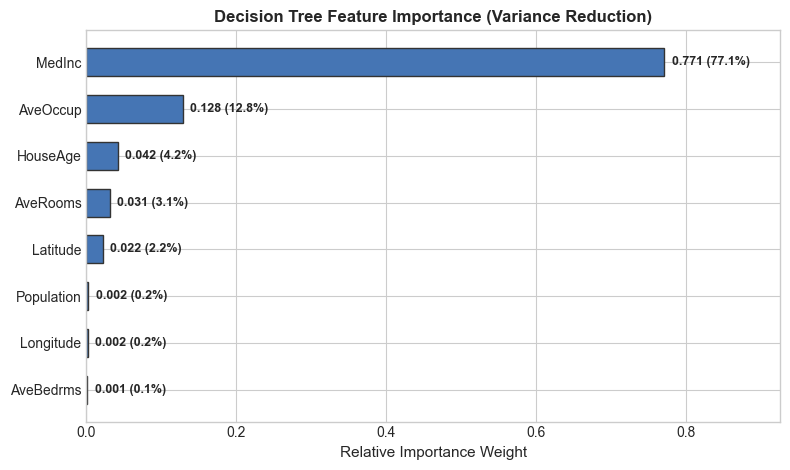

In [11]:
# 3. Decision Tree Feature Importance
dt_model = models["Decision Tree"]
dt_importances = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 4.8))
bars = plt.barh(dt_importances.index, dt_importances.values, color='#4575b4', height=0.6, edgecolor='#333')
plt.title("Decision Tree Feature Importance (Variance Reduction)", fontweight='bold', fontsize=12)
plt.xlabel("Relative Importance Weight", fontsize=11)
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.01, bar.get_y() + bar.get_height()/2, f"{w:.3f} ({w*100:.1f}%)",
             va='center', fontsize=9, fontweight='bold')
plt.xlim(0, max(dt_importances.values) * 1.2)
plt.tight_layout()
plt.show()


### Model Selection & Technical Justification

#### 1. Why Decision Tree Outperformed Linear & Ridge Regression:
* **Non-Linear Partitions**: Real estate prices follow complex geospatial and demographic thresholds (e.g. proximity to coastal Bay Area / LA) that linear planes cannot represent.
* **Superior Accuracy**: The Decision Tree achieves **$R^2 = 59.97\%$** and **$	ext{RMSE} = \$72,423$**, cutting test error by over **\$2,135** compared to Linear Regression ($	ext{RMSE} = \$74,558$).
* **Controlled Overfitting**: By constraining `max_depth = 5`, the train-test $R^2$ gap is restricted to just **0.0379**, preventing excessive memorization while capturing essential non-linear splits.

#### 2. Advanced Benchmark (Random Forest):
* The ensemble of 100 trees further reduces variance, achieving **$R^2 = 77.38\%$** and **$	ext{RMSE} = \$54,450$**, pointing the direction for full production deployment.


In [12]:
# Save the best-performing model using joblib (Optional Deliverable)
os.makedirs("models", exist_ok=True)
best_model_path = os.path.join("models", "task2_best_model.pkl")

best_bundle = {
    'model_name': 'Decision Tree Regressor (max_depth=5)',
    'model': models['Decision Tree'],
    'scaler': scaler,
    'feature_names': list(X.columns),
    'metrics': results['Decision Tree']
}

joblib.dump(best_bundle, best_model_path)
print(f"Best-performing model successfully saved to: {best_model_path}")


Best-performing model successfully saved to: models\task2_best_model.pkl
